# M6 Assignment: Understanding Permutation Tests

This week’s assignment is a "choice" assignment, which can be applied to your contract but is not required. It has two parts that build on the same idea: how to test whether an observed difference could just be the result of chance.

**Part 1** uses our small employee satisfaction survey. You’ll test whether satisfaction differs by gender by simulating the world where **gender labels don’t influence satisfaction** and comparing your observed difference to that random world.

**Part 2** returns to your "Only One Test" analysis and re-does it using a permutation test. The details will differ, but the logic will be the same.

The focus this week is on *how* permutation tests work — what the null hypothesis means, how to translate it into code, and how to interpret the results.

---

Please read these instructions carefully before you begin:

- **AI use**: You may use AI to *ask questions* if you are stuck or need clarification. You're also free to use AI to complete individual lines of code. Do not, however, copy and paste from AI or use a tool like Copilot to write whole sections of code. The purpose of this assignment is for you to gain fluency with statistical concepts through hands-on coding.
- **Questions**: Look for cells marked with `Q:`. These contain questions you must answer in Markdown.
- **Markdown**: Use Markdown cells to explain your results, interpret outputs, and format your answers neatly.
- **Visualizations**: Create clear, well-labeled plots. Always include titles, axis labels, and legends where appropriate. For visualizations, make a basic visualization without using AI. Then feel free to ask the AI to "make this beautiful". You can copy and paste that code.

When you've finished your work, ensure your notebook runs top-to-bottom without errors, then commit and push your changes to GitHub.

---

## Part 1: Survey Analysis

In this first part you’ll work with an employee satisfaction survey. Each record includes an employee’s gender, location, tenure, and satisfaction rating on a 1–7 scale. A few missing values have been added so you can practice filling them in.

You’ll move through the steps below:

1. **Read and describe the data.**  
   Get a sense of what’s in the file and how complete it is.

2. **Fill in missing values.**  
   Use simple replacements (like the mean or most common value) so the dataset is ready to analyze.

3. **Compare mean satisfaction by gender.**  
   Compute the average satisfaction by gender. Calculate the average satisfaction for men and women. Then you'll do a permutation test to assess the statistical significance of the difference.

4. **Compare the proportion satisfied by gender.**  
   Define “satisfied” as ratings ≥ 4. Then measure how the share of satisfied employees differs between men and women.

5. **Compare non-binary respondents to everyone else.**  
   Treat the “non-binary” group as one category and compare their satisfaction rate (i.e., the portion who are satisfied) to the combined man/woman group.

The null hypothesis behind all of these comparisons is that gender doesn't influence satisfaction. This is equivalent to saying that the gender labels might as well have been randomly assigned. Thus, if we shuffled them at random, the differences we see in satisfaction would look much the same. That idea will guide how we implement the permutation test later.



### Step 1 – Read and describe the data

Start by reading the file `satisfaction_survey.txt`.  
Take a quick look at the columns, data types, and a few sample rows.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(442)
survey = pd.read_csv("satisfaction_survey.txt", sep="\t")
survey.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   employee_id   300 non-null    object 
 1   gender        297 non-null    object 
 2   location      295 non-null    object 
 3   tenure        298 non-null    float64
 4   satisfaction  300 non-null    int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 11.8+ KB


In [2]:
survey.head()

,employee_id,gender,location,tenure,satisfaction
0,AQ1600314,man,Seattle,0.9,4
1,AQ1808649,man,Seattle,4.3,4
2,AQ1850081,man,New York,1.2,4
3,AQ1929192,man,Seattle,1.5,4
4,AQ1238345,man,New York,NaN,4


In [3]:
survey["gender"].value_counts()

gender
man        181
woman      106
neither     10
Name: count, dtype: int64

In [4]:
survey["location"].value_counts()

location
Seattle     149
New York    146
Name: count, dtype: int64

### Step 2 – Handle missing values

Check which variables have missing values and fill them so the dataset is complete.  
Use the mean for numeric fields and the most common value (mode) for strings.  
When you’re done, confirm that no missing values remain.


In [5]:
survey.isna().sum()

employee_id     0
gender          3
location        5
tenure          2
satisfaction    0
dtype: int64

In [6]:
survey["gender"] =  survey["gender"].apply(lambda x: str(x) if pd.notnull(x) else None)
survey["location"] = survey["location"].apply(lambda s: str(s) if pd.notnull(s) else None)

In [7]:
survey["tenure"] = survey["tenure"].fillna(survey["tenure"].mean())
survey["tenure"] = survey["tenure"].round(2)

In [8]:
survey["gender"] = survey["gender"].fillna(survey["gender"].mode()[0])
survey["location"] = survey["location"].fillna(survey["location"].mode()[0])

### Step 3 – Compare mean satisfaction by gender

Compute the mean satisfaction for men and for women, and take their difference.  
We’ll use this difference in the permutation test later.

**Null hypothesis:** gender labels don’t influence satisfaction.


In [9]:
satisfaction_mean = survey.groupby("gender")["satisfaction"].mean()
print(satisfaction_mean)

gender
man        4.195652
neither    3.300000
woman      3.622642
Name: satisfaction, dtype: float64


0.57


<Axes: title={'center': 'Average Satisfaction by Gender'}, xlabel='gender'>

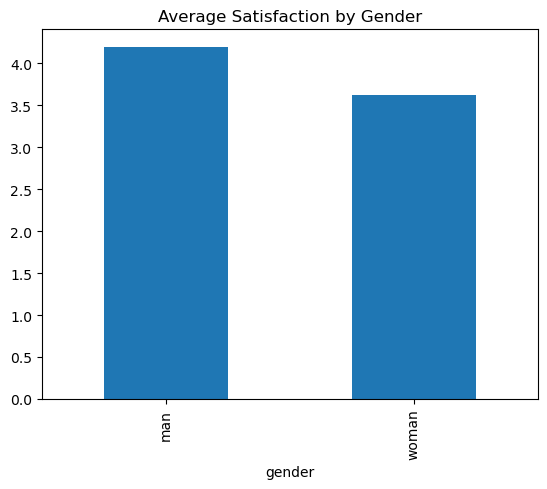

In [10]:
# Compute the difference in satisfaction and store the result
gender_satisfaction_mean_difference = satisfaction_mean["man"] - satisfaction_mean["woman"]
print(f"{gender_satisfaction_mean_difference:.2f}")

# Make a simple bar plot of the relative satisfaction of men and women
filtered_mean = satisfaction_mean.loc[["man", "woman"]]
satisfaction_df = filtered_mean.reset_index()
satisfaction_df.columns = ['gender', 'satisfaction']

satisfaction_df.plot.bar(x='gender', y='satisfaction', legend=False, title='Average Satisfaction by Gender')


Q: Based on the results of your analysis, how does satisfaction vary between men and women? 

A: <!-- Your answer here -->Men report higher average satisfaction than women, this suggests men are slightly more satisfied in the surveyed group.

--- 

### Step 4 – Permutation test for mean difference

If gender has no influence, randomly shuffling the gender column should make no difference to average satisfaction.

Shuffle the gender labels, recompute the difference in means many times, and compare those simulated differences to the observed one.

You can use a similar trick to the one we've been using in the "only one test" framework. Start by making a copy of the survey data and call it something like `survey_replicate`. Make an empty list to store your results and create a `for` loop. In this loop, assign a scrambled gender column into `survey_replicate`. You can do that with a line of code like this: 
```
survey_replicate['gender'] = survey_replicate['gender'].sample(n=len(survey_replicate),replace=False)
```

After you've created your scrambled column, calculate the difference in satisfaction for men and women on this new data set. Store the results in your list. 

At the end of the `for` loop you can plot the results with a histogram and report on how extreme the actual results appear to be, under your null hypothesis.


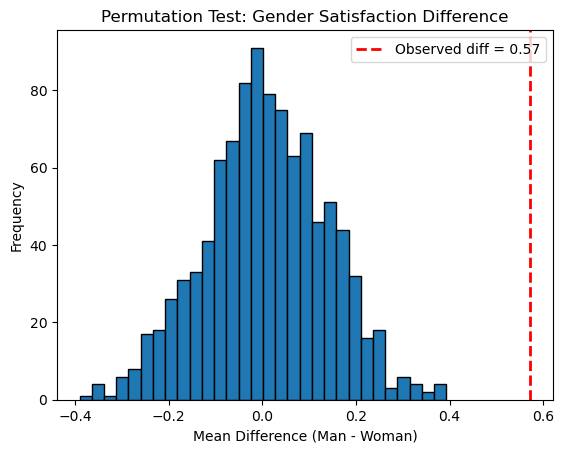

In [11]:
# Your code here, don't forget to plot your results

num_sim = 1000
diffs = []

gender_array = survey["gender"].values.copy()
satisfaction_array = survey["satisfaction"].values

for _ in range(num_sim):
    np.random.shuffle(gender_array)  
    
  
    man_mean = satisfaction_array[gender_array == "man"].mean()
    woman_mean = satisfaction_array[gender_array == "woman"].mean()
    diff = man_mean - woman_mean
    diffs.append(diff)


plt.hist(diffs, bins=30, edgecolor='black')
plt.axvline(gender_satisfaction_mean_difference, color='red', linestyle='dashed', linewidth=2, label=f'Observed diff = {gender_satisfaction_mean_difference:.2f}')
plt.title("Permutation Test: Gender Satisfaction Difference")
plt.xlabel("Mean Difference (Man - Woman)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [12]:
p_val = sum(abs(d) >= abs(gender_satisfaction_mean_difference) for d in diffs) / num_sim
print(f'p-value: {p_val:.4f}')

p-value: 0.0000


Q: How does the observed difference compare to the null distribution? What does the p-value suggest?

A: <!-- Your answer here --> The observed difference of 0.57 lies far to the right of the null distribution, which is centered around zero. Zero is the expected difference if gender labels don’t influence satisfaction. The p-value is 0.000, meaning that none of the 1000 simulated differences were as extreme as the observed one. This suggests that such a large difference is extremely unlikely to occur by chance alone. Therefore, we have very strong evidence to reject the null hypothesis and conclude that gender likely influences satisfaction in this dataset.

### Step 5 – Compare proportion satisfied by gender

Create a new column, `satisfied`, that is true for ratings > 4.  
Compute the proportion satisfied for men and women and measure the difference using the same permutation technique as above. Again make a plot and report on the fraction of observations that are as extreme as the result you found in the un-permuted data.


In [13]:
# Your code here
survey["satisfied"] = survey["satisfaction"] > 4
survey["satisfied"].head()

0    False
1    False
2    False
3    False
4    False
Name: satisfied, dtype: bool

In [14]:
gender_satisfied = survey.groupby("gender")["satisfied"].mean()
print(gender_satisfied)

gender
man        0.364130
neither    0.000000
woman      0.198113
Name: satisfied, dtype: float64


In [15]:
observed_diff = gender_satisfied["man"] - gender_satisfied["woman"]
print(f"Observed Gender Satisfied difference: {observed_diff:.2f}")

Observed Gender Satisfied difference: 0.17


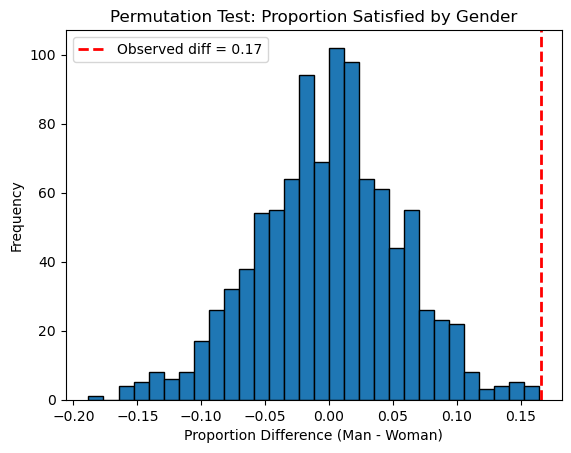

In [16]:
gender_array = survey["gender"].values.copy() 
satisfied_diffs = []
satisfied_array = survey["satisfied"].values
for _ in range(num_sim):
    np.random.shuffle(gender_array)
    man_prop = satisfied_array[gender_array == "man"].mean()
    woman_prop = satisfied_array[gender_array == "woman"].mean()
    prop_diff = man_prop - woman_prop
    satisfied_diffs.append(prop_diff)
    
plt.hist(satisfied_diffs, bins=30, edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2,
            label=f'Observed diff = {observed_diff:.2f}')
plt.title("Permutation Test: Proportion Satisfied by Gender")
plt.xlabel("Proportion Difference (Man - Woman)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [17]:
p_value = sum(abs(d) >= abs(observed_diff) for d in satisfied_diffs) / num_sim
print(f"p-value: {p_value:.4f}")

p-value: 0.0010


Q: Our metric "satisified" is a cruder measure of satisfaction than our means. How do the proportions of “satisfied” employees compare between men and women?

A: <!-- Your answer here --> Men show a higher proportion of satisfied employees compared to women, with an observed difference of 0.17 (17%).  In our permutation test, only 0.1% (p-value = 0.0010) of the simulated samples produced a difference as extreme or more extreme than this observed value. Since this is well below the conventional 0.05 significance threshold, we have strong evidence to reject the null hypothesis. This confirms that the gender satisfaction gap exists not only in mean scores but also in the proportion of employees who are highly satisfied

### Step 6 – Compare non-binary respondents to everyone else

Using your `satisfied` column, now compare the satisfaction of non-binary respondents to men and women together. 



In [18]:
survey["gender_binary"] = survey["gender"].apply( lambda x: "neither" if x == "neither" else "man or woman")
binary_satisfied = survey.groupby("gender_binary")["satisfied"].mean()
print(binary_satisfied)

gender_binary
man or woman    0.303448
neither         0.000000
Name: satisfied, dtype: float64


In [19]:
observed_diff_binary = binary_satisfied["neither"] - binary_satisfied["man or woman"]
print(f"Observed difference (neither - man or woman): {observed_diff_binary:.2f}")

Observed difference (neither - man or woman): -0.30


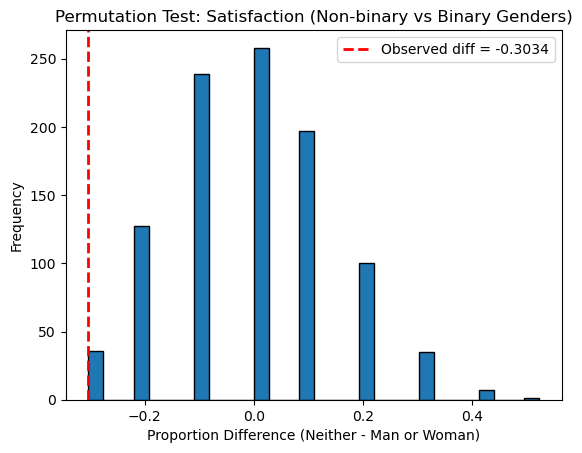

In [20]:
# Your code here
binary_diffs = []
gender_binary_array = survey["gender_binary"].values.copy()
satisfied_array = survey["satisfied"].values.copy()


for _ in range(num_sim):
    np.random.shuffle(gender_binary_array)
    neither_prop = satisfied_array[gender_binary_array == "neither"].mean()
    man_woman_prop = satisfied_array[gender_binary_array == "man or woman"].mean()
    binary_diff = neither_prop - man_woman_prop
    binary_diffs.append(binary_diff)

plt.hist(binary_diffs, bins=30, edgecolor='black')
plt.axvline(observed_diff_binary, color='red', linestyle='dashed', linewidth=2,
            label=f'Observed diff = {observed_diff_binary:.4f}')
plt.title("Permutation Test: Satisfaction (Non-binary vs Binary Genders)")
plt.xlabel("Proportion Difference (Neither - Man or Woman)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [21]:
p_val_binary = sum(abs(d) >= abs(observed_diff_binary) for d in binary_diffs) / num_sim
print(f"p-value: {p_val_binary:.4f}")

p-value: 0.0790


Q: How does satisfaction among non-binary respondents compare to others? Can you draw a firm conclusion?

A: <!-- Your answer here --> Nonbinary people in the survey were much less satisfied than others. None of them said they were satisfied, while about 30 percent of men and women did. That is a big difference. But because there were only 10 nonbinary respondents, it is difficult to know if this result is meaningful. The p-value was 0.0790, which means we fail to reject the null hypothesis. However, we cannot draw a firm conclusion because the nonbinary group is so small.

--- 

### Part 1 Reflection

In a Markdown cell, give me an overview of this section. Tell me how your understanding of employee satisfaction changed as you went through the various tests. This is also a place to ask me any questions about concepts that are unclear. 


### Final Reflection

This assignment was really interesting.

In Part 1, I looked at satisfaction scores across gender groups. I found that men had higher average satisfaction than women and nonbinary respondents. The p-values were very low (0.000 and 0.001), so I rejected the null hypothesis and concluded that gender does influence satisfaction. For nonbinary respondents, the difference was large, but the p-value was 0.079, and since the sample size was only 10, I couldn’t draw a firm conclusion.

I sometimes get confused between “rejecting” and “failing to reject” the null hypothesis, especially when the null is worded as a negative. But I’m starting to get it: if the p-value is low, we reject the idea that gender doesn’t matter, which means gender *does* influence satisfaction.

I also calculated a two-tailed p-value, even though in class we used a one-tailed test. I think I understand tails now. They represent how extreme the result is compared to what we’d expect by chance.

I noticed my code had a lot of repetition. I could have written a function to make it cleaner, but I went step by step and realized it at the end. I also used LLM to make the graph.

My hypothesis in the "Only One Test" assignment was that the average odometer reading for High Efficiency Sedans would be higher than for Trucks/Utility Vehicles. The null hypothesis would be that it is not higher or is the same. So, I tested whether high-efficiency sedans have higher odometer readings than trucks and utility vehicles. My observed difference was 6746.22 and the p-value was 0.000, so I rejected the null hypothesis again. That means high-efficiency sedans *do* have significantly higher odometer readings.

At first, I got a different observed value than I did in the “Only One Test” assignment. I couldn’t figure out why. Then I realized I had dropped the missing price row in Assignment 4, which probably caused the mismatch.

I kept this part pretty straightforward: selected the columns I needed and ran the permutation test. My observed difference was 6746.22, which was different from Assignment 4 because of the dropped rows, and the p-value was 0.000. That means the result is very unlikely to be due to chance.


<!-- Your response here. Remember to remove these 
     comment characters at the beginning and end. -->

---

## Part 2: Re-doing Your Analysis Using a Permutation Test

Return to the analysis you did in your “Only One Test” assignment.  
You’ll re-run that analysis, this time using a **permutation test** to generate your reference distribution instead of the sampling approach you used before.

Follow the same basic logic as in Part 1:

1. Identify the two groups or conditions you compared.  
2. Compute the observed test statistic (the difference or effect you’re measuring).  
3. Write code that shuffles or reassigns labels to simulate what the data would look like if the null hypothesis were true.  
4. Collect those simulated statistics to form your reference distribution.  
5. Compare your observed statistic to that distribution to estimate a p-value.

You do not need to reproduce the full “sampling from the population” structure from the previous version. Focus only on the permutation logic: how random reassignment under the null creates the comparison you need.

Once you’ve completed your analysis, fill in the table below to map your example onto the **Only One Test** framework.


In [22]:
# Your code here, but make as many
# code cells as you need.
# Remember to plot your results and calculate your
# p-value, the fraction of observations as extreme
# or more extreme than your result.
listings = pd.read_csv("data.csv")

In [23]:
filtered_listings = listings[listings["model"].isin(["prius", "camry", "accord", "wrangler", "f150"])].reset_index()[["model", "odometer"]]

In [24]:
filtered_listings.head()

,model,odometer
0,accord,64300.0
1,accord,70000.0
2,accord,362018.0
3,accord,235112.0
4,accord,61000.0


In [25]:
filtered_listings.isna().sum()

model         0
odometer    301
dtype: int64

In [26]:
odometer_median = filtered_listings["odometer"].median()
filtered_listings["odometer"] = filtered_listings["odometer"].fillna(odometer_median)

In [27]:
def categorize_vehicle(model):
    if model in ["prius", "camry", "accord"]:
        return "High Efficiency Sedans"
    elif model in ["f150", "wrangler"]:
        return "Trucks / Utility Vehicles"
    else:
        return "other"

In [28]:
filtered_listings["vehicle_category"] = filtered_listings["model"].apply(categorize_vehicle)

In [29]:
print(filtered_listings["vehicle_category"].value_counts())

vehicle_category
High Efficiency Sedans       160446
Trucks / Utility Vehicles     98337
Name: count, dtype: int64


In [30]:
high_eff = filtered_listings.loc[filtered_listings["vehicle_category"] == "High Efficiency Sedans"]["odometer"].values
truck = filtered_listings[filtered_listings["vehicle_category"] == "Trucks / Utility Vehicles"]["odometer"].values

In [31]:
high_eff_avg = high_eff.mean()
truck_avg = truck.mean()
print(f' High Efficiency Sedans Avg Odometer -> {high_eff_avg:.2f} and Trucks / Utility Vehicles Avg Odometer -> {truck_avg:.2f}')

 High Efficiency Sedans Avg Odometer -> 150492.67 and Trucks / Utility Vehicles Avg Odometer -> 143746.45


In [32]:
obs_diff = high_eff_avg - truck_avg
print(f"Observed difference (High Efficiency Sedans - Trucks): {obs_diff:.2f}")

Observed difference (High Efficiency Sedans - Trucks): 6746.22


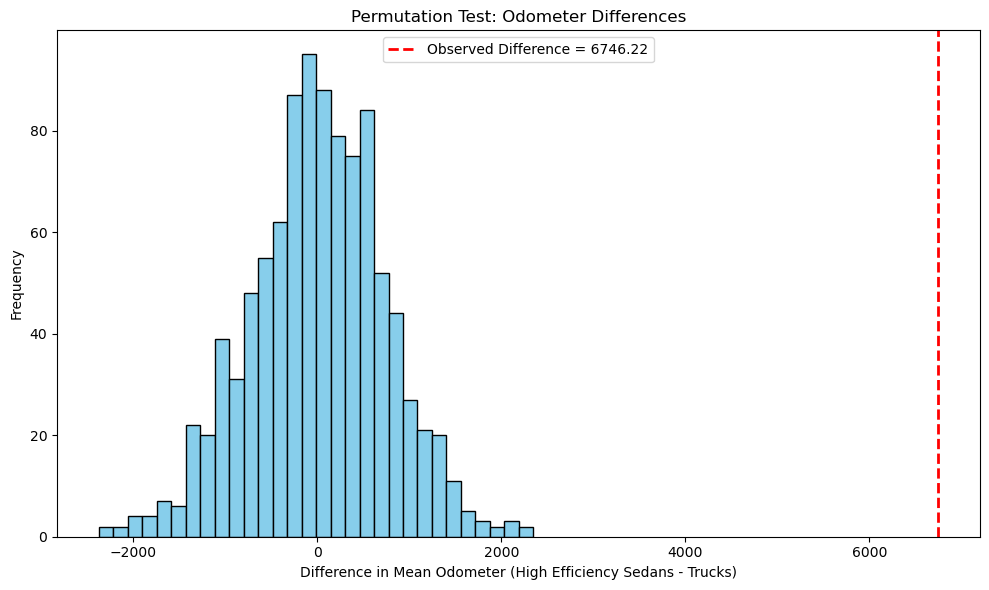

In [33]:
n = 1000
differences = []
combined = np.concatenate([high_eff, truck])

for _ in range(n):
    np.random.shuffle(combined)
    upper_half = combined[:len(high_eff)]  
    lower_half = combined[len(high_eff):]  
    diff = upper_half.mean() - lower_half.mean()
    differences.append(diff)

plt.figure(figsize=(10, 6))
plt.hist(differences, bins=30, color='skyblue', edgecolor='black')
plt.axvline(obs_diff, color='red', linestyle='dashed', linewidth=2, 
            label=f'Observed Difference = {obs_diff:.2f}')
plt.xlabel('Difference in Mean Odometer (High Efficiency Sedans - Trucks)')
plt.ylabel('Frequency')
plt.title('Permutation Test: Odometer Differences')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
p_value = np.mean(np.abs(differences) >= np.abs(obs_diff))
print(f"P-value: {p_value:.4f}")

P-value: 0.0000


### Mapping your permutation test to the Only One Test framework

Use the table below to summarize how your permutation test fits each element of the framework. Consider this whole table one big `Q:` block.

| Element from OOT | In your example |
|:--|:--|
| **1. Data** | Odometer readings from vehicles categorized as High Efficiency Sedans and Trucks / Utility Vehicles. |
| **2. Test statistic** | Difference in mean odometer values between the two vehicle categories. |
| **3. Observed value or effect** | 6746.22 -> High Efficiency Sedans had a higher average odometer than Trucks. |
| **4. Null hypothesis** | There is no real difference in odometer readings between High Efficiency Sedans and Trucks. Any observed difference is due to chance. |
| **5. How you simulate data under the null** | Combine all odometer values, shuffle them, and randomly split into two groups of the same sizes as the originals. |
| **6. Description of the reference distribution** | A histogram of 1000 simulated differences in mean odometer values from the shuffled data. |
| **7. p-value from comparing observed to simulated** | 0.0000 -> the observed difference was more extreme than any of the simulated ones. |

---

### A quick note on Markdown tables

Tables in Markdown are built from rows and columns separated by vertical bars (`|`).  
The header row comes first, followed by a line of dashes to mark the column break, and then one row per entry.  
You can type directly into the cells above — no special formatting beyond the bars and line breaks is required.
